# Modelos de predicción de cantidades mensuales por lonja

Este notebook contiene los tres modelos de predicción:
- **Modelo 1: LSTM – Cantidad mensual por lonja**
- **Modelo 2: Prophet – Cantidad mensual por lonja**
- **Modelo 3: XGBoost – Cantidad mensual por lonja**


---

# Modelo 1: LSTM – Cantidad mensual por lonja

---

### Predicción de cantidad mensual por lonja con LSTM

#### Contexto

Mismo pipeline que `LSTM_ingresos_mensuales`, pero en lugar de predecir
los ingresos totales de todas las lonjas agregadas, se entrena **un modelo
LSTM independiente por cada lonja**.

Esto permite obtener predicciones específicas para la planificación
individual de cada lonja gallega.

#### ¿Por qué LSTM?
Las redes LSTM (Long Short-Term Memory) son un tipo de red neuronal recurrente
especialmente diseñadas para aprender patrones en **series temporales**.
A diferencia de modelos como XGBoost que tratan cada fila como independiente,
las LSTM "recuerdan" el contexto de meses anteriores para hacer su predicción.

#### Cambios respecto a la versión agregada:

| Versión agregada | Esta versión (por lonja) |
|---|---|
| Agrupa por `(anio, mes)` | Agrupa por `(lonxa, anio, mes)` |
| 1 modelo LSTM | 1 modelo LSTM por lonja |
| 1 serie temporal (~80 meses) | N series temporales (una por lonja) |
| Tabla `gold_predicciones_lstm` | Tabla `gold_predicciones_lstm_cantidad_lonxa` |

#### Ventaja: capturan dependencias a largo plazo (estacionalidad anual, tendencias).
#### Limitación: necesitan más datos y son más costosas de entrenar que modelos clásicos.

#### Orden de ejecución:
1. `Gold_base_analitica` → tabla base
2. **Este notebook** → predicción mensual de ingresos por lonja con LSTM


## Propósito de este notebook:
-   Leer la tabla `gold_base_analitica`
-   Agregar los datos a nivel mensual **por lonja** (ingresos totales, variables oceanográficas medias)
-   Para cada lonja: crear features temporales y de ventana, entrenar un modelo LSTM, evaluar y predecir
-   Guardar predicciones y métricas con la columna `lonxa` identificativa

In [1]:
# Instalación de TensorFlow/Keras (descomentar si no está disponible en el entorno)
%pip install --upgrade tensorflow protobuf==3.20.3 --quiet

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 8, Finished, Available, Finished, False)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fsspec-wrapper 0.1.15 requires PyJWT>=2.6.0, but you have pyjwt 2.4.0 which is incompatible.
nni 3.0 requires filelock<3.12, but you have filelock 3.13.1 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.



In [4]:
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import tensorflow as tf

import pyspark.sql.functions as F
from pyspark.sql.functions import col, lit, current_timestamp
from pyspark.sql.functions import sum as _sum, avg as _avg, count as _count
from pyspark.sql.functions import year, month, round as _round

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 12, Finished, Available, Finished, False)

In [5]:
df_ml = spark.read.table("gold_base_analitica")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 13, Finished, Available, Finished, False)

## Agregación mensual de cantidad por lonja

A diferencia de la versión agregada, aquí agrupamos por `(lonxa, anio, mes)`
para obtener una serie temporal independiente por cada lonja.

- `ingresos`: suma de (precio × cantidad) de todas las operaciones del mes
- `cantidad_total`: kg totales vendidos en el mes
- `num_operaciones`: número de ventas realizadas en el mes
- `temperatura_c`, `salinidad_psu`, `velocidad_mar`: medias mensuales de las variables oceanográficas

In [6]:
# 1. Agregar a nivel mensual POR LONJA
df_mensual = (
    df_ml
    .withColumn("anio", F.year("data"))
    .withColumn("mes", F.month("data"))
    .groupBy("lonxa", "anio", "mes")
    .agg(
        F.round(F.sum("cantidad"), 2).alias("cantidad_total"),
        F.count("*").alias("num_operaciones"),
        F.round(F.avg("temperatura_c"), 3).alias("temp_media"),
        F.round(F.avg("salinidad_psu"), 3).alias("salinidad_media"),
        F.round(F.avg("velocidad_mar"), 3).alias("velocidad_media")
    )
)

# ── NUEVO PASO: CALCULAR EL TOP 5 LONJAS CON MÁS FACTURACIÓN ─────────────────
# Agrupamos todo el histórico por lonja, sumamos sus INGRESOS y nos quedamos con las 5 mejores
top_5_pyspark = (
    df_mensual
    .groupBy("lonxa")
    .agg(F.round(F.sum("cantidad_total"), 2).alias("facturacion_historica"))
    .orderBy(F.col("facturacion_historica").desc())
    .limit(5)
)

# Extraemos los nombres de las 5 lonjas a una lista de Python
top_5_lonjas = [row["lonxa"] for row in top_5_pyspark.collect()]
print(f"Top 5 lonjas con más facturación: {top_5_lonjas}")

# Filtramos nuestro DataFrame mensual para quedarnos ÚNICAMENTE con esas 5 lonjas
df_mensual_top5 = df_mensual.filter(F.col("lonxa").isin(top_5_lonjas))
# ─────────────────────────────────────────────────────────────────────────────

# 2. Convertir a Pandas y ordenar (Usando el DataFrame filtrado del Top 5)
df_pandas = df_mensual_top5.toPandas()

df_pandas["fecha"] = pd.to_datetime(
    df_pandas["anio"].astype(str) + "-" + df_pandas["mes"].astype(str) + "-01"
)

df_pandas = df_pandas.sort_values(["lonxa", "fecha"]).reset_index(drop=True)

# El bucle ahora solo procesará de forma automática tus 5 lonjas principales
lonjas = sorted(df_pandas["lonxa"].unique())
print(f"\nLonjas analizadas (Top 5): {len(lonjas)}")

for lj in lonjas:
    n = len(df_pandas[df_pandas["lonxa"] == lj])
    print(f"  · {lj}: {n} meses")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 14, Finished, Available, Finished, False)

Top 5 lonjas con más facturación: ['A Coruña (Lonja Coruña, S.A.)', 'Vigo', 'Ribeira', 'Burela', 'Celeiro']

Lonjas analizadas (Top 5): 5
  · A Coruña (Lonja Coruña, S.A.): 96 meses
  · Burela: 96 meses
  · Celeiro: 96 meses
  · Ribeira: 96 meses
  · Vigo: 96 meses


### Visualización de la serie temporal por lonja

Antes de modelar, es fundamental entender el patrón de cada serie. Buscamos:
- **Tendencia**: ¿los ingresos suben o bajan con los años?
- **Estacionalidad**: ¿hay meses que siempre son más altos/bajos?

In [26]:
fig, axes = plt.subplots(
    nrows=(len(lonjas) + 2) // 3, ncols=3,
    figsize=(18, 4 * ((len(lonjas) + 2) // 3)),
    squeeze=False
)
for idx, lj in enumerate(lonjas):
    ax = axes[idx // 3][idx % 3]
    df_lj = df_pandas[df_pandas["lonxa"] == lj]
    ax.plot(df_lj["fecha"], df_lj["cantidad_total"], marker="o", markersize=2)
    ax.set_title(lj, fontsize=10)
    ax.set_ylabel("Cantidad (kg)")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

# Ocultar ejes sobrantes
for idx in range(len(lonjas), axes.size):
    axes[idx // 3][idx % 3].set_visible(False)

plt.suptitle("Cantidad mensual por lonja", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Entrenamiento de un modelo LSTM por lonja

Para cada lonja se sigue el mismo pipeline que en la versión agregada:

1. **Feature Engineering**: crear `lag_1`, `lag_12`, `media_3m`, `mes_sin`, `mes_cos`
   más las variables oceanográficas y operacionales
2. **Separar** train (hasta dic-2023) / test (ene-2024+)
3. **Normalizar** con MinMaxScaler (fit solo en train)
4. **Crear secuencias** de LOOKBACK meses para la LSTM
5. **Entrenar** modelo LSTM con EarlyStopping
6. **Evaluar** con RMSE, MAE, MAPE, R²

Las lonjas con menos de 24 meses de datos (tras eliminar NaN de lags)
se omiten porque no hay suficiente historia para entrenar y evaluar.

### Arquitectura del modelo LSTM (por lonja)

Diseño sencillo con dos capas LSTM y dropout para regularización:

1. **LSTM(64 unidades)**: primera capa recurrente, devuelve la secuencia completa
2. **Dropout(0.2)**: desactiva el 20% de neuronas para evitar sobreajuste
3. **LSTM(32 unidades)**: segunda capa que comprime la información temporal
4. **Dropout(0.2)**: segunda capa de regularización
5. **Dense(1)**: capa final que produce la predicción de ingresos

Se usa el optimizador Adam y la función de pérdida MSE (Error Cuadrático Medio).
Lookback de 3 meses porque las series por lonja tienen pocos puntos (~80 meses).


In [11]:
FEATURES = [
    "lag_1", "lag_12", "media_3m",
    "cantidad_total", "num_operaciones",
    "temp_media", "salinidad_media", "velocidad_media",
    "mes_sin", "mes_cos"
]
TARGET = "cantidad_total"
LOOKBACK = 12  # Meses de contexto que ve la LSTM

def crear_secuencias(X, y, lookback):
    """
    Transforma arrays 2D en secuencias 3D para la LSTM.
    Cada muestra contiene 'lookback' pasos temporales.
    """
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])  # ventana de 'lookback' meses
        ys.append(y[i])               # valor a predecir
    return np.array(Xs), np.array(ys)

# Almacenamos resultados de todas las lonjas
resultados_pred = []       # predicciones
resultados_metricas = []   # métricas por lonja

for lj in lonjas:
    print(f"\n{'='*60}")
    print(f"  LONJA: {lj}")
    print(f"{'='*60}")

    # ── 1. Filtrar datos de esta lonja ──
    df_lj = df_pandas[df_pandas["lonxa"] == lj].copy().reset_index(drop=True)

    # ── 2. Feature Engineering ──
    df_lj["lag_1"]    = df_lj["cantidad_total"].shift(1)
    df_lj["lag_12"]   = df_lj["cantidad_total"].shift(12)
    df_lj["media_3m"] = df_lj["cantidad_total"].rolling(window=3).mean()
    df_lj["mes_sin"]  = np.sin(2 * np.pi * df_lj["mes"] / 12.0)
    df_lj["mes_cos"]  = np.cos(2 * np.pi * df_lj["mes"] / 12.0)

    # Eliminar filas con NaN generados por los lags (primeros 12 meses)
    df_lj = df_lj.dropna().reset_index(drop=True)

    if len(df_lj) < 24:
        print(f"  OMITIDA: solo {len(df_lj)} meses (mínimo 24)")
        continue

    # ── 3. Separación temporal train / test ──
    corte = df_lj["fecha"] < "2024-01-01"
    df_train = df_lj[corte].copy()
    df_test  = df_lj[~corte].copy()

    if len(df_test) == 0:
        print(f"  OMITIDA: sin datos de test (todo anterior a 2024)")
        continue

    print(f"  Train: {len(df_train)} meses  |  Test: {len(df_test)} meses")

    # ── 4. Normalización (fit solo con train para evitar data leakage) ──
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(df_train[FEATURES].values)
    y_train_scaled = scaler_y.fit_transform(df_train[[TARGET]].values)

    X_test_scaled = scaler_X.transform(df_test[FEATURES].values)
    y_test_scaled = scaler_y.transform(df_test[[TARGET]].values)

    # ── 5. Crear secuencias para la LSTM ──
    X_train_seq, y_train_seq = crear_secuencias(X_train_scaled, y_train_scaled, LOOKBACK)
    X_test_seq,  y_test_seq  = crear_secuencias(X_test_scaled,  y_test_scaled,  LOOKBACK)

    # Verificar que hay suficientes secuencias de test
    if len(X_test_seq) == 0:
        print(f"  OMITIDA: sin secuencias de test suficientes (test={len(df_test)}, lookback={LOOKBACK})")
        continue

    print(f"  Secuencias train: {X_train_seq.shape}  |  Secuencias test: {X_test_seq.shape}")

    # ── 6. Baseline: lag_1 (ingresos del mes anterior) ──
    y_test_real = df_test[TARGET].values[LOOKBACK:]  # alineamos con las secuencias
    y_baseline  = df_test["lag_1"].values[LOOKBACK:]

    rmse_bl = mean_squared_error(y_test_real, y_baseline) ** 0.5
    mae_bl  = mean_absolute_error(y_test_real, y_baseline)
    mape_bl = mean_absolute_percentage_error(y_test_real, y_baseline)
    r2_bl   = r2_score(y_test_real, y_baseline)

    # ── 7. Construir y entrenar modelo LSTM ──
    modelo_lstm = Sequential([
        LSTM(64, return_sequences=True, input_shape=(LOOKBACK, len(FEATURES))),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(1)
    ])
    modelo_lstm.compile(optimizer="adam", loss="mse")

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    historia = modelo_lstm.fit(
        X_train_seq, y_train_seq,
        epochs=200,
        batch_size=16, #########
        validation_split=0.15,
        callbacks=[early_stop],
        verbose=0  # Silencioso para no saturar la salida en el bucle
    )

    print(f"  Entrenamiento finalizado en {len(historia.history['loss'])} épocas")

    # ── 8. Predicción y desnormalización ──
    y_pred_scaled = modelo_lstm.predict(X_test_seq, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()

    # ── 9. Métricas ──
    rmse = mean_squared_error(y_test_real, y_pred) ** 0.5
    mae  = mean_absolute_error(y_test_real, y_pred)
    mape = mean_absolute_percentage_error(y_test_real, y_pred)
    r2   = r2_score(y_test_real, y_pred)

    mejora_mape = (1 - mape / mape_bl) * 100 if mape_bl > 0 else 0.0

    print(f"  LSTM:     RMSE={rmse:,.2f}  MAE={mae:,.2f}  MAPE={mape:.4f}  R²={r2:.4f}")
    print(f"  BASELINE: RMSE={rmse_bl:,.2f}  MAE={mae_bl:,.2f}  MAPE={mape_bl:.4f}  R²={r2_bl:.4f}")
    print(f"  Mejora MAPE: {mejora_mape:.1f}%")

    # ── 10. Guardar predicciones de esta lonja ──
    fechas_test_lj = df_test["fecha"].values[LOOKBACK:]
    for i in range(len(y_test_real)):
        resultados_pred.append({
            "lonxa": lj,
            "fecha": fechas_test_lj[i],
            "cantidad_real": y_test_real[i],
            "cantidad_predicho": float(y_pred[i]),
            "error_absoluto": abs(y_test_real[i] - y_pred[i]),
            "error_pct": abs(y_test_real[i] - y_pred[i]) / y_test_real[i] * 100
        })

    # ── 11. Guardar métricas de esta lonja ──
    resultados_metricas.append({
        "lonxa": lj,
        "rmse": float(rmse), "mae": float(mae),
        "mape": float(mape), "r2": float(r2),
        "baseline_rmse": float(rmse_bl), "baseline_mae": float(mae_bl),
        "baseline_mape": float(mape_bl), "baseline_r2": float(r2_bl),
        "mejora_mape_pct": float(mejora_mape)
    })

print(f"\n\nModelos entrenados: {len(resultados_metricas)} lonjas")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 19, Finished, Available, Finished, False)

/nfs4/pyenv-d8ef5ac3-c8cd-4081-9cdc-e2b5e80d5b36/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/nfs4/pyenv-d8ef5ac3-c8cd-4081-9cdc-e2b5e80d5b36/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/nfs4/pyenv-d8ef5ac3-c8cd-4081-9cdc-e2b5e80d5b36/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/nfs4/pyenv-d8ef5ac3-c8cd-40

  Entrenamiento finalizado en 38 épocas
  Entrenamiento finalizado en 25 épocas
  LSTM:     RMSE=335,814.51  MAE=288,939.35  MAPE=0.1997  R²=-0.4091
  BASELINE: RMSE=337,639.22  MAE=285,448.85  MAPE=0.1820  R²=-0.4245
  Mejora MAPE: -9.7%


Modelos entrenados: 5 lonjas


### Resumen de métricas por lonja

In [12]:
df_metricas = pd.DataFrame(resultados_metricas)
display(df_metricas.sort_values("mape"))

print(f"\nMAPE medio across lonjas: {df_metricas['mape'].mean():.4f}")
print(f"R² medio across lonjas:   {df_metricas['r2'].mean():.4f}")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 20, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, e47c3216-dca1-470e-8929-f1f769ee3234)


MAPE medio across lonjas: 0.4178
R² medio across lonjas:   -0.6002


### Gráfico: valores reales vs predicciones por lonja

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 21, Finished, Available, Finished, False)

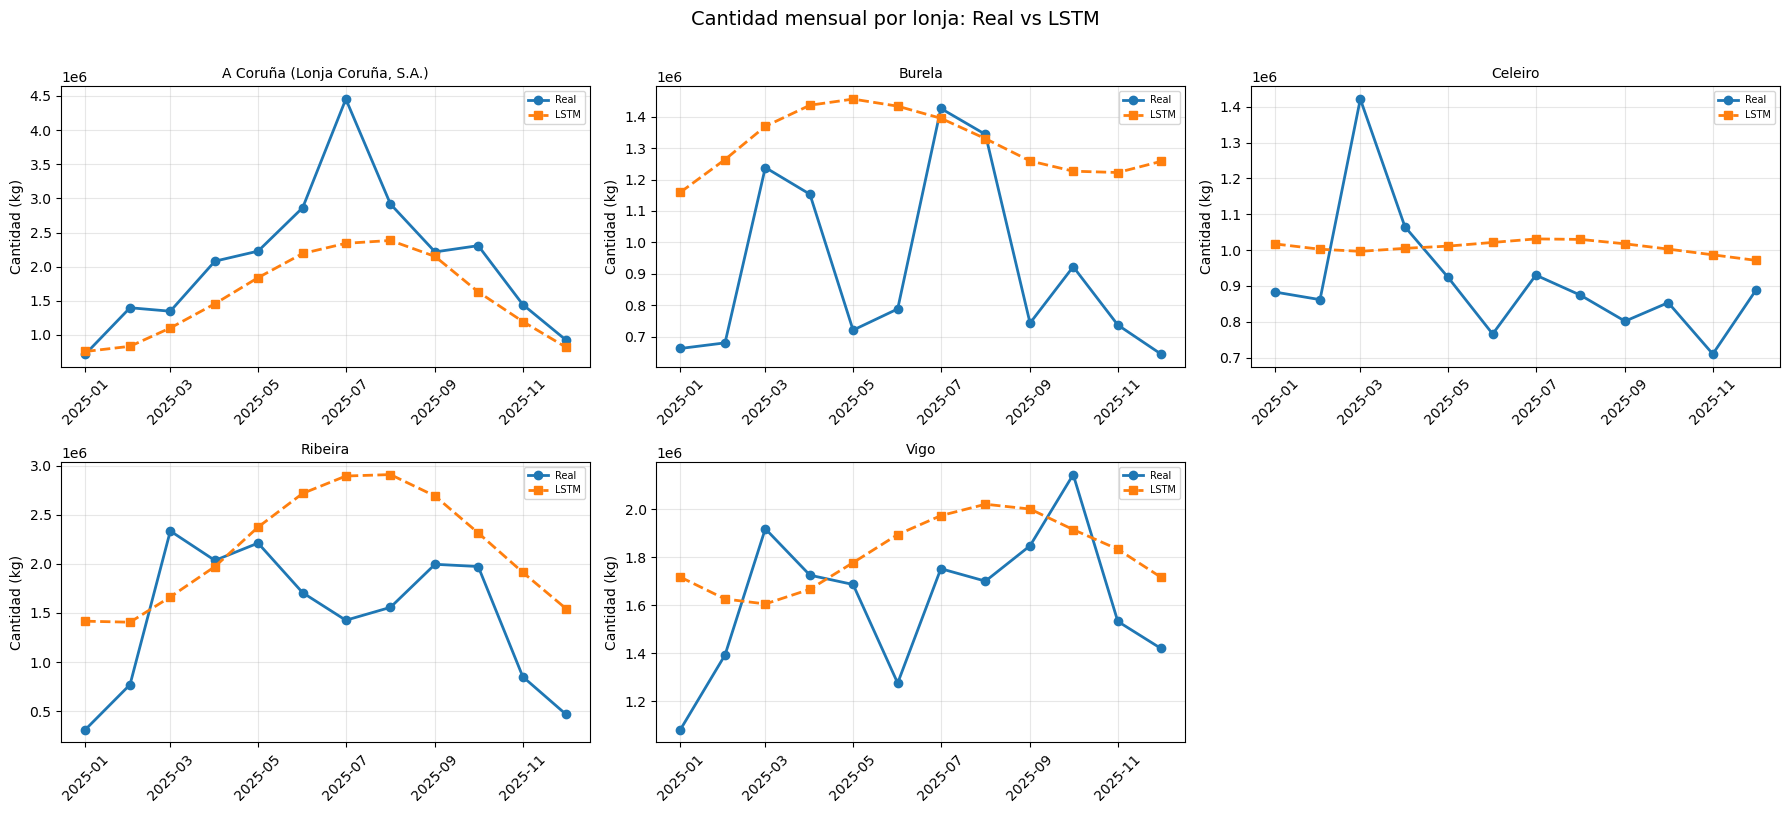

In [13]:
df_pred_all = pd.DataFrame(resultados_pred)
lonjas_pred = df_pred_all["lonxa"].unique()

fig, axes = plt.subplots(
    nrows=(len(lonjas_pred) + 2) // 3, ncols=3,
    figsize=(18, 4 * ((len(lonjas_pred) + 2) // 3)),
    squeeze=False
)
for idx, lj in enumerate(lonjas_pred):
    ax = axes[idx // 3][idx % 3]
    df_lj = df_pred_all[df_pred_all["lonxa"] == lj]
    ax.plot(df_lj["fecha"].values, df_lj["cantidad_real"].values,
            marker="o", label="Real", linewidth=2)
    ax.plot(df_lj["fecha"].values, df_lj["cantidad_predicho"].values,
            marker="s", label="LSTM", linewidth=2, linestyle="--")
    ax.set_title(lj, fontsize=10)
    ax.set_ylabel("Cantidad (kg)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

for idx in range(len(lonjas_pred), axes.size):
    axes[idx // 3][idx % 3].set_visible(False)

plt.suptitle("Cantidad mensual por lonja: Real vs LSTM", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Registro en MLflow

In [14]:
mlflow.set_experiment("cantidad_mensual_por_lonxa")

with mlflow.start_run(run_name="lstm_cantidad_por_lonxa"):

    mlflow.log_params({
        "modelo": "LSTM_por_lonxa",
        "lookback": LOOKBACK,
        "lstm_units_1": 64,
        "lstm_units_2": 32,
        "dropout": 0.2,
        "optimizer": "adam",
        "batch_size": 32,
        "features": str(FEATURES),
        "num_lonjas": len(resultados_metricas)
    })

    mlflow.log_metrics({
        "mape_medio": df_metricas["mape"].mean(),
        "r2_medio": df_metricas["r2"].mean(),
        "rmse_medio": df_metricas["rmse"].mean(),
        "mae_medio": df_metricas["mae"].mean(),
    })

    print("Métricas registradas en MLflow")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 22, Finished, Available, Finished, False)

2026/06/10 20:37:19 INFO mlflow.tracking.fluent: Experiment with name 'cantidad_mensual_por_lonxa' does not exist. Creating a new experiment.


Métricas registradas en MLflow


## Guardar predicciones en gold_predicciones_lstm_cantidad_lonxa

In [15]:
df_pred_spark = spark.createDataFrame(df_pred_all)

df_pred_spark \
    .withColumn("modelo", lit("LSTM_por_lonxa")) \
    .withColumn("fecha_ejecucion", current_timestamp()) \
    .write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("gold_predicciones_lstm_cantidad_lonxa")

#print(f"Predicciones guardadas: {df_pred_spark.count()} filas")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 23, Finished, Available, Finished, False)

## Guardar métricas en gold_metricas_modelo

In [16]:
from datetime import datetime
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType, TimestampType
)

schema = StructType([
    StructField("modelo", StringType()),
    StructField("lonxa", StringType()),
    StructField("rmse", DoubleType()),
    StructField("mae", DoubleType()),
    StructField("mape", DoubleType()),
    StructField("r2", DoubleType()),
    StructField("baseline_rmse", DoubleType()),
    StructField("baseline_mae", DoubleType()),
    StructField("baseline_mape", DoubleType()),
    StructField("baseline_r2", DoubleType()),
    StructField("mejora_mape_pct", DoubleType()),
    StructField("fecha_entrenamiento", TimestampType()),
    StructField("hiperparametros", StringType())
])

hiperparams = str({
    "lookback": LOOKBACK,
    "lstm_units": [64, 32],
    "dropout": 0.2,
    "optimizer": "adam",
    "batch_size": 32,
    "features": FEATURES
})

log_data = [
    (
        "LSTM_por_lonxa",
        row["lonxa"],
        row["rmse"], row["mae"], row["mape"], row["r2"],
        row["baseline_rmse"], row["baseline_mae"],
        row["baseline_mape"], row["baseline_r2"],
        row["mejora_mape_pct"],
        datetime.now(),
        hiperparams
    )
    for row in resultados_metricas
]

spark.createDataFrame(log_data, schema=schema) \
    .write \
    .format("delta") \
    .option("mergeSchema", "true") \
    .mode("append") \
    .saveAsTable("gold_metricas_modelo")

print("Métricas guardadas en gold_metricas_modelo")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 24, Finished, Available, Finished, False)

Métricas guardadas en gold_metricas_modelo


---

# Modelo 2: Prophet – Cantidad mensual por lonja

---

### Predicción de cantidad mensual (kg) por lonja con Prophet

#### Contexto

Mismo pipeline que `PROPHET_cantidad_mensual`, pero en lugar de predecir
la cantidad total de todas las lonjas agregadas, se entrena **un modelo
Prophet independiente por cada lonja**.

La predicción de cantidad es **independiente** de la de ingresos.

#### ¿Para qué sirve predecir la cantidad por lonja?
- Planificación logística específica de cada lonja (cámaras, hielo, personal).
- Previsión de capacidad de transporte por punto de descarga.
- Indicador adelantado de la actividad pesquera por zona.

#### Orden de ejecución:
1. `Gold_base_analitica` → tabla base
2. **Este notebook** → predicción mensual de cantidad por lonja con Prophet

## Propósito de este notebook:
-   Leer la tabla `gold_base_analitica`
-   Agregar los datos a nivel mensual **por lonja** (cantidad total, variables oceanográficas medias)
-   Para cada lonja: preparar datos Prophet, entrenar, evaluar y predecir
-   Guardar predicciones y métricas con la columna `lonxa` identificativa

In [33]:
# Instalación de Prophet (descomentar si no está disponible en el entorno)
# %pip install prophet --quiet

In [17]:
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyspark.sql.functions as F
from pyspark.sql.functions import col, lit, current_timestamp
from pyspark.sql.functions import sum as _sum, avg as _avg, count as _count
from pyspark.sql.functions import year, month, round as _round

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 25, Finished, Available, Finished, False)

In [18]:
df_ml = spark.read.table("gold_base_analitica")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 26, Finished, Available, Finished, False)

## Agregación mensual de cantidad por lonja

Agrupamos por `(lonxa, anio, mes)` para obtener la cantidad total vendida
y las condiciones oceanográficas medias de cada lonja cada mes.

In [19]:
from pyspark.sql import functions as F
 
# 1. Agregar a nivel mensual POR LONJA (Tu código original intacto)
df_mensual = (
    df_ml
    .withColumn("anio", F.year("data"))
    .withColumn("mes", F.month("data"))
    .groupBy("lonxa", "anio", "mes")
    .agg(
        F.round(F.sum("cantidad"), 2).alias("cantidad_total"),
        F.count("*").alias("num_operaciones"),
        F.round(F.avg("temperatura_c"), 3).alias("temp_media"),
        F.round(F.avg("salinidad_psu"), 3).alias("salinidad_media"),
        F.round(F.avg("velocidad_mar"), 3).alias("velocidad_media")
    )
)
 
# ── NUEVO PASO: CALCULAR EL TOP 5 LONJAS CON MÁS FACTURACIÓN ─────────────────
# Agrupamos todo el histórico por lonja, sumamos su cantidad total y nos quedamos con las 5 mejores
top_5_pyspark = (
    df_mensual
    .groupBy("lonxa")
    .agg(F.sum("cantidad_total").alias("facturacion_historica"))
    .orderBy(F.col("facturacion_historica").desc())
    .limit(5)
)
 
# Extraemos los nombres de las 5 lonjas a una lista de Python
top_5_lonjas = [row["lonxa"] for row in top_5_pyspark.collect()]
print(f"Top 5 lonjas con más facturación: {top_5_lonjas}")
 
# Filtramos nuestro DataFrame mensual para quedarnos ÚNICAMENTE con esas 5 lonjas
df_mensual_top5 = df_mensual.filter(F.col("lonxa").isin(top_5_lonjas))
# ─────────────────────────────────────────────────────────────────────────────
 
# 2. Convertir a Pandas y ordenar (Modificado para usar el dataframe filtrado del Top 5)
df_pandas = df_mensual_top5.toPandas()
 
df_pandas["fecha"] = pd.to_datetime(
    df_pandas["anio"].astype(str) + "-" + df_pandas["mes"].astype(str) + "-01"
)
 
df_pandas = df_pandas.sort_values(["lonxa", "fecha"]).reset_index(drop=True)
 
# El bucle ahora solo procesará de forma automática tus 5 lonjas principales
lonjas = sorted(df_pandas["lonxa"].unique())
print(f"\nLonjas analizadas (Top 5): {len(lonjas)}")
 
for lj in lonjas:
    n = len(df_pandas[df_pandas["lonxa"] == lj])
    print(f"  · {lj}: {n} meses") 

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 27, Finished, Available, Finished, False)

Top 5 lonjas con más facturación: ['A Coruña (Lonja Coruña, S.A.)', 'Vigo', 'Ribeira', 'Burela', 'Celeiro']

Lonjas analizadas (Top 5): 5
  · A Coruña (Lonja Coruña, S.A.): 96 meses
  · Burela: 96 meses
  · Celeiro: 96 meses
  · Ribeira: 96 meses
  · Vigo: 96 meses


In [20]:
# # Agregar a nivel mensual POR LONJA
# df_mensual = (
#     df_ml
#     .withColumn("anio", year("data"))
#     .withColumn("mes", month("data"))
#     .groupBy("lonxa", "anio", "mes")
#     .agg(
#         _round(_sum("cantidad"), 2).alias("cantidad_total"),
#         _count("*").alias("num_operaciones"),
#         _round(_avg("temperatura_c"), 3).alias("temp_media"),
#         _round(_avg("salinidad_psu"), 3).alias("salinidad_media"),
#         _round(_avg("velocidad_mar"), 3).alias("velocidad_media")
#     )
# )

# # Convertir a Pandas y ordenar
# df_pandas = df_mensual.toPandas()
# df_pandas["fecha"] = pd.to_datetime(
#     df_pandas["anio"].astype(str) + "-" + df_pandas["mes"].astype(str) + "-01"
# )
# df_pandas = df_pandas.sort_values(["lonxa", "fecha"]).reset_index(drop=True)

# lonjas = sorted(df_pandas["lonxa"].unique())
# print(f"Lonjas encontradas: {len(lonjas)}")
# for lj in lonjas:
#     n = len(df_pandas[df_pandas["lonxa"] == lj])
#     print(f"  {lj}: {n} meses")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 28, Finished, Available, Finished, False)

### Visualización de la serie temporal por lonja

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 29, Finished, Available, Finished, False)

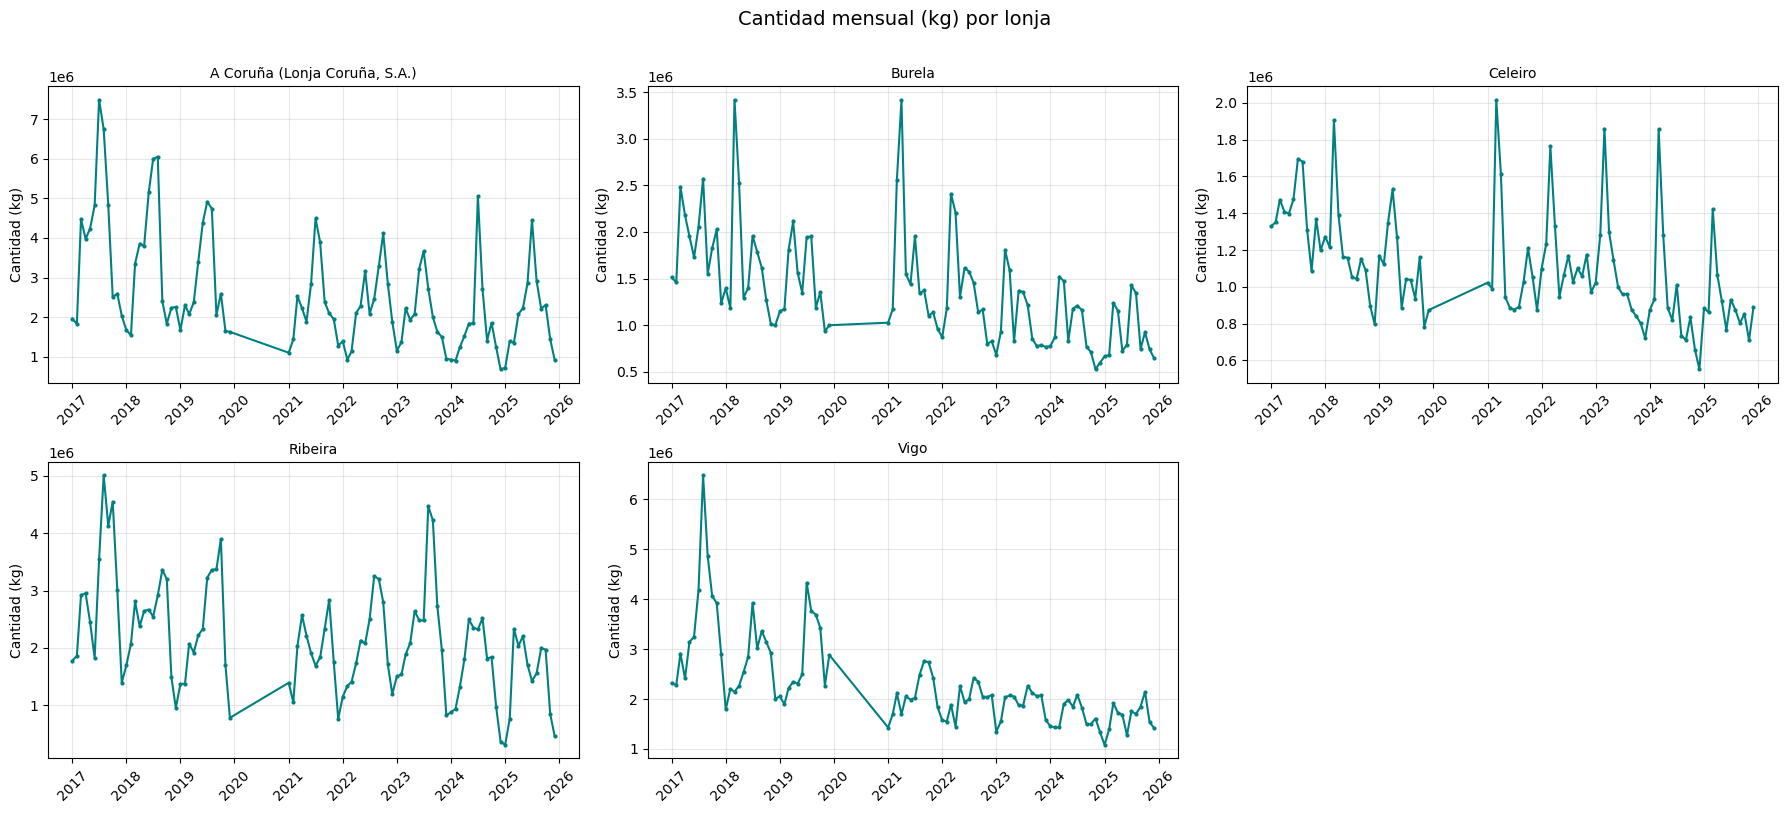

In [21]:
fig, axes = plt.subplots(
    nrows=(len(lonjas) + 2) // 3, ncols=3,
    figsize=(18, 4 * ((len(lonjas) + 2) // 3)),
    squeeze=False
)
for idx, lj in enumerate(lonjas):
    ax = axes[idx // 3][idx % 3]
    df_lj = df_pandas[df_pandas["lonxa"] == lj]
    ax.plot(df_lj["fecha"], df_lj["cantidad_total"], marker="o", markersize=2, color="teal")
    ax.set_title(lj, fontsize=10)
    ax.set_ylabel("Cantidad (kg)")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

for idx in range(len(lonjas), axes.size):
    axes[idx // 3][idx % 3].set_visible(False)

plt.suptitle("Cantidad mensual (kg) por lonja", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Entrenamiento de un modelo Prophet por lonja

Para cada lonja se sigue el mismo pipeline que en la versión agregada:
1. Crear `lag_12`, `rolling_3m`, `rolling_6m` como regresores legítimos
2. Separar train (hasta dic-2023) / test (ene-2024+)
3. Entrenar Prophet con estacionalidad multiplicativa
4. Evaluar con RMSE, MAE, MAPE, R²

Las lonjas con menos de 24 meses de datos se omiten.

In [22]:
REGRESORES = ["lag_12", "rolling_3m", "rolling_6m"]

resultados_pred = []
resultados_metricas = []

for lj in lonjas:
    print(f"\n{'='*60}")
    print(f"  LONJA: {lj}")
    print(f"{'='*60}")

    df_lj = df_pandas[df_pandas["lonxa"] == lj].copy().reset_index(drop=True)

    # Crear lags y rolling sobre la serie de esta lonja
    df_lj["lag_12"] = df_lj["cantidad_total"].shift(12)
    df_lj["rolling_3m"] = df_lj["cantidad_total"].rolling(3).mean()
    df_lj["rolling_6m"] = df_lj["cantidad_total"].rolling(6).mean()

    # Formato Prophet
    df_prophet = df_lj[["fecha", "cantidad_total"]].copy()
    df_prophet.columns = ["ds", "y"]
    for reg in REGRESORES:
        df_prophet[reg] = df_lj[reg].values

    df_prophet = df_prophet.dropna().reset_index(drop=True)

    if len(df_prophet) < 24:
        print(f"  OMITIDA: solo {len(df_prophet)} meses (mínimo 24)")
        continue

    # Separación temporal train / test
    corte = df_prophet["ds"] < "2024-01-01"
    df_train = df_prophet[corte].copy()
    df_test = df_prophet[~corte].copy()

    if len(df_test) == 0:
        print(f"  OMITIDA: sin datos de test (todo anterior a 2024)")
        continue

    print(f"  Train: {len(df_train)} meses  |  Test: {len(df_test)} meses")

    # Baseline: lag_12
    y_test_real = df_test["y"].values
    y_baseline_arr = df_test["lag_12"].values

    rmse_bl = mean_squared_error(y_test_real, y_baseline_arr) ** 0.5
    mae_bl = mean_absolute_error(y_test_real, y_baseline_arr)
    mape_bl = mean_absolute_percentage_error(y_test_real, y_baseline_arr)
    r2_bl = r2_score(y_test_real, y_baseline_arr)

    # Entrenar Prophet
    modelo = Prophet(
        changepoint_prior_scale=0.062,
        seasonality_prior_scale=10.5,
        seasonality_mode='multiplicative',
        yearly_seasonality=6,
        weekly_seasonality=False,
        daily_seasonality=False,
    )
    for reg in REGRESORES:
        modelo.add_regressor(reg, mode='multiplicative')

    modelo.fit(df_train)

    # Predecir
    df_futuro = df_test[["ds"] + REGRESORES].copy()
    forecast = modelo.predict(df_futuro)
    y_pred = forecast["yhat"].values

    # Métricas
    rmse = mean_squared_error(y_test_real, y_pred) ** 0.5
    mae = mean_absolute_error(y_test_real, y_pred)
    mape = mean_absolute_percentage_error(y_test_real, y_pred)
    r2 = r2_score(y_test_real, y_pred)

    mejora_mape = (1 - mape / mape_bl) * 100 if mape_bl > 0 else 0.0

    print(f"  PROPHET:  RMSE={rmse:,.2f}  MAE={mae:,.2f}  MAPE={mape:.4f}  R²={r2:.4f}")
    print(f"  BASELINE: RMSE={rmse_bl:,.2f}  MAE={mae_bl:,.2f}  MAPE={mape_bl:.4f}  R²={r2_bl:.4f}")
    print(f"  Mejora MAPE: {mejora_mape:.1f}%")

    for i in range(len(df_test)):
        resultados_pred.append({
            "lonxa": lj,
            "fecha": df_test["ds"].iloc[i],
            "cantidad_real": y_test_real[i],
            "cantidad_predicho": y_pred[i],
            "cantidad_lower": forecast["yhat_lower"].values[i],
            "cantidad_upper": forecast["yhat_upper"].values[i],
            "error_absoluto": abs(y_test_real[i] - y_pred[i]),
            "error_pct": abs(y_test_real[i] - y_pred[i]) / y_test_real[i] * 100
        })

    resultados_metricas.append({
        "lonxa": lj,
        "rmse": float(rmse), "mae": float(mae),
        "mape": float(mape), "r2": float(r2),
        "baseline_rmse": float(rmse_bl), "baseline_mae": float(mae_bl),
        "baseline_mape": float(mape_bl), "baseline_r2": float(r2_bl),
        "mejora_mape_pct": float(mejora_mape)
    })

print(f"\n\nModelos entrenados: {len(resultados_metricas)} lonjas")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 30, Finished, Available, Finished, False)

20:38:17 - cmdstanpy - INFO - Chain [1] start processing
20:38:18 - cmdstanpy - INFO - Chain [1] done processing
20:38:18 - cmdstanpy - INFO - Chain [1] start processing


  PROPHET:  RMSE=89,044.00  MAE=70,232.65  MAPE=0.0796  R²=0.8872
  BASELINE: RMSE=179,701.01  MAE=136,180.83  MAPE=0.1563  R²=0.5407
  Mejora MAPE: 49.1%

  LONJA: Ribeira
  Train: 60 meses  |  Test: 24 meses
  PROPHET:  RMSE=326,902.99  MAE=263,743.39  MAPE=0.2301  R²=0.7748
  BASELINE: RMSE=829,708.83  MAE=604,104.18  MAPE=0.4907  R²=-0.4507
  Mejora MAPE: 53.1%

  LONJA: Vigo
  Train: 60 meses  |  Test: 24 meses
  PROPHET:  RMSE=191,021.34  MAE=143,919.98  MAPE=0.0844  R²=0.4775
  BASELINE: RMSE=360,726.54  MAE=299,235.12  MAPE=0.1885  R²=-0.8631
  Mejora MAPE: 55.2%


Modelos entrenados: 5 lonjas


### Resumen de métricas por lonja

In [23]:
df_metricas = pd.DataFrame(resultados_metricas)
display(df_metricas.sort_values("mape"))

print(f"\nMAPE medio across lonjas: {df_metricas['mape'].mean():.4f}")
print(f"R² medio across lonjas:   {df_metricas['r2'].mean():.4f}")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 31, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, dcb2144b-db4d-4329-8212-a015ddcbc1a4)


MAPE medio across lonjas: 0.1464
R² medio across lonjas:   0.6606


### Gráfico: valores reales vs predicciones por lonja

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 32, Finished, Available, Finished, False)

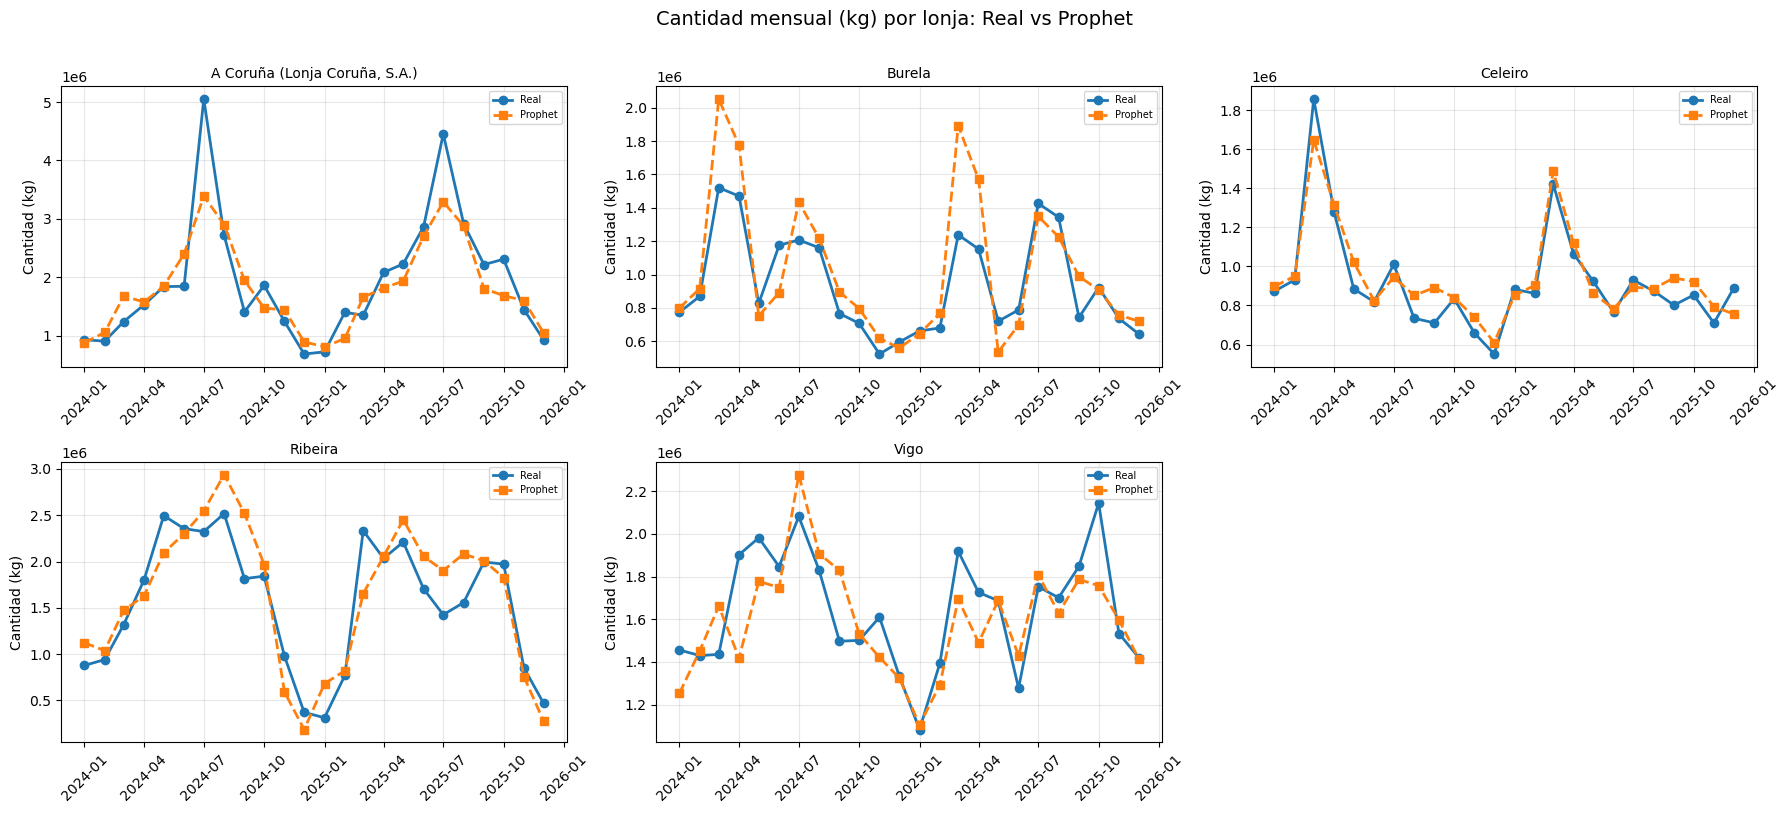

In [24]:
df_pred_all = pd.DataFrame(resultados_pred)
lonjas_pred = df_pred_all["lonxa"].unique()

fig, axes = plt.subplots(
    nrows=(len(lonjas_pred) + 2) // 3, ncols=3,
    figsize=(18, 4 * ((len(lonjas_pred) + 2) // 3)),
    squeeze=False
)
for idx, lj in enumerate(lonjas_pred):
    ax = axes[idx // 3][idx % 3]
    df_lj = df_pred_all[df_pred_all["lonxa"] == lj]
    ax.plot(df_lj["fecha"].values, df_lj["cantidad_real"].values,
            marker="o", label="Real", linewidth=2)
    ax.plot(df_lj["fecha"].values, df_lj["cantidad_predicho"].values,
            marker="s", label="Prophet", linewidth=2, linestyle="--")
    ax.set_title(lj, fontsize=10)
    ax.set_ylabel("Cantidad (kg)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

for idx in range(len(lonjas_pred), axes.size):
    axes[idx // 3][idx % 3].set_visible(False)

plt.suptitle("Cantidad mensual (kg) por lonja: Real vs Prophet", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Registro en MLflow

In [25]:
mlflow.set_experiment("cantidad_mensual_por_lonxa")

with mlflow.start_run(run_name="prophet_cantidad_por_lonxa"):

    mlflow.log_params({
        "modelo": "Prophet_cantidad_por_lonxa",
        "target": "cantidad_total",
        "changepoint_prior_scale": 0.062,
        "seasonality_prior_scale": 10.5,
        "seasonality_mode": "multiplicative",
        "yearly_seasonality_fourier": 6,
        "regresores": str(REGRESORES),
        "num_lonjas": len(resultados_metricas)
    })

    mlflow.log_metrics({
        "mape_medio": df_metricas["mape"].mean(),
        "r2_medio": df_metricas["r2"].mean(),
        "rmse_medio": df_metricas["rmse"].mean(),
        "mae_medio": df_metricas["mae"].mean(),
    })

    print("Métricas registradas en MLflow")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 33, Finished, Available, Finished, False)

Métricas registradas en MLflow


## Guardar predicciones en gold_predicciones_prophet_cantidad_lonxa

In [26]:
df_pred_spark = spark.createDataFrame(df_pred_all)

df_pred_spark \
    .withColumn("modelo", lit("Prophet_cantidad_por_lonxa")) \
    .withColumn("fecha_ejecucion", current_timestamp()) \
    .write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("gold_predicciones_prophet_cantidad_lonxa")

print(f"Predicciones guardadas: {df_pred_spark.count()} filas")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 34, Finished, Available, Finished, False)

Predicciones guardadas: 120 filas


## Guardar métricas en gold_metricas_modelo

In [27]:
from datetime import datetime
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType, TimestampType
)

schema = StructType([
    StructField("modelo", StringType()),
    StructField("lonxa", StringType()),
    StructField("rmse", DoubleType()),
    StructField("mae", DoubleType()),
    StructField("mape", DoubleType()),
    StructField("r2", DoubleType()),
    StructField("baseline_rmse", DoubleType()),
    StructField("baseline_mae", DoubleType()),
    StructField("baseline_mape", DoubleType()),
    StructField("baseline_r2", DoubleType()),
    StructField("mejora_mape_pct", DoubleType()),
    StructField("fecha_entrenamiento", TimestampType()),
    StructField("hiperparametros", StringType())
])

hiperparams = str({
    "changepoint_prior_scale": 0.062,
    "seasonality_prior_scale": 10.5,
    "seasonality_mode": "multiplicative",
    "yearly_seasonality_fourier": 6,
    "regresores": REGRESORES
})

log_data = [
    (
        "Prophet_cantidad_por_lonxa",
        row["lonxa"],
        row["rmse"], row["mae"], row["mape"], row["r2"],
        row["baseline_rmse"], row["baseline_mae"],
        row["baseline_mape"], row["baseline_r2"],
        row["mejora_mape_pct"],
        datetime.now(),
        hiperparams
    )
    for row in resultados_metricas
]

spark.createDataFrame(log_data, schema=schema) \
    .write \
    .format("delta") \
    .option("mergeSchema", "true") \
    .mode("append") \
    .saveAsTable("gold_metricas_modelo")

print("Métricas guardadas en gold_metricas_modelo")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 35, Finished, Available, Finished, False)

Métricas guardadas en gold_metricas_modelo


---

# Modelo 3: XGBoost – Cantidad mensual por lonja

---

### Predicción de cantidad mensual (kg) por lonja con XGBoost

#### Contexto

Mismo pipeline que `XGBOOST_cantidad_mensual`, pero en lugar de predecir
la cantidad total de todas las lonjas agregadas, se entrena **un modelo
XGBoost independiente por cada lonja**.

La predicción de cantidad es **independiente** de la de ingresos.

#### ¿Por qué XGBoost por lonja para cantidad?
- Cada lonja tiene un volumen de actividad diferente y un mix de especies propio.
- Un modelo por lonja captura mejor esos patrones locales.
- XGBoost es rápido de entrenar, por lo que escalar a N lonjas es viable.

#### Orden de ejecución:
1. `Gold_base_analitica` → tabla base
2. **Este notebook** → predicción mensual de cantidad por lonja con XGBoost

## Propósito de este notebook:
-   Leer la tabla `gold_base_analitica`
-   Agregar los datos a nivel mensual **por lonja** (cantidad total, variables oceanográficas medias)
-   Para cada lonja: crear features temporales, entrenar XGBoost, evaluar y predecir
-   Guardar predicciones y métricas con la columna `lonxa` identificativa

In [28]:
import mlflow
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyspark.sql.functions as F
from pyspark.sql.functions import col, lit, current_timestamp
from pyspark.sql.functions import sum as _sum, avg as _avg, count as _count
from pyspark.sql.functions import year, month, round as _round

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from xgboost import XGBRegressor

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 36, Finished, Available, Finished, False)

In [29]:
df_ml = spark.read.table("gold_base_analitica")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 37, Finished, Available, Finished, False)

## Agregación mensual de cantidad por lonja

Agrupamos por `(lonxa, anio, mes)` para obtener la cantidad total vendida
y las condiciones oceanográficas medias de cada lonja cada mes.

In [30]:
# # Agregar a nivel mensual POR LONJA
# df_mensual = (
#     df_ml
#     .withColumn("anio", year("data"))
#     .withColumn("mes", month("data"))
#     .groupBy("lonxa", "anio", "mes")
#     .agg(
#         _round(_sum("cantidad"), 2).alias("cantidad_total"),
#         _count("*").alias("num_operaciones"),
#         _round(_avg("temperatura_c"), 3).alias("temp_media"),
#         _round(_avg("salinidad_psu"), 3).alias("salinidad_media"),
#         _round(_avg("velocidad_mar"), 3).alias("velocidad_media")
#     )
# )

# # Convertir a Pandas y ordenar
# df_pandas = df_mensual.toPandas()
# df_pandas["fecha"] = pd.to_datetime(
#     df_pandas["anio"].astype(str) + "-" + df_pandas["mes"].astype(str) + "-01"
# )
# df_pandas = df_pandas.sort_values(["lonxa", "fecha"]).reset_index(drop=True)

# lonjas = sorted(df_pandas["lonxa"].unique())
# print(f"Lonjas encontradas: {len(lonjas)}")
# for lj in lonjas:
#     n = len(df_pandas[df_pandas["lonxa"] == lj])
#     print(f"  {lj}: {n} meses")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 38, Finished, Available, Finished, False)

In [31]:
from pyspark.sql import functions as F
 
# 1. Agregar a nivel mensual POR LONJA (Tu código original intacto)
df_mensual = (
    df_ml
    .withColumn("anio", F.year("data"))
    .withColumn("mes", F.month("data"))
    .groupBy("lonxa", "anio", "mes")
    .agg(
        F.round(F.sum("cantidad"), 2).alias("cantidad_total"),
        F.count("*").alias("num_operaciones"),
        F.round(F.avg("temperatura_c"), 3).alias("temp_media"),
        F.round(F.avg("salinidad_psu"), 3).alias("salinidad_media"),
        F.round(F.avg("velocidad_mar"), 3).alias("velocidad_media")
    )
)
 
# ── NUEVO PASO: CALCULAR EL TOP 5 LONJAS CON MÁS FACTURACIÓN ─────────────────
# Agrupamos todo el histórico por lonja, sumamos su cantidad total y nos quedamos con las 5 mejores
top_5_pyspark = (
    df_mensual
    .groupBy("lonxa")
    .agg(F.sum("cantidad_total").alias("facturacion_historica"))
    .orderBy(F.col("facturacion_historica").desc())
    .limit(5)
)
 
# Extraemos los nombres de las 5 lonjas a una lista de Python
top_5_lonjas = [row["lonxa"] for row in top_5_pyspark.collect()]
print(f"Top 5 lonjas con más facturación: {top_5_lonjas}")
 
# Filtramos nuestro DataFrame mensual para quedarnos ÚNICAMENTE con esas 5 lonjas
df_mensual_top5 = df_mensual.filter(F.col("lonxa").isin(top_5_lonjas))
# ─────────────────────────────────────────────────────────────────────────────
 
# 2. Convertir a Pandas y ordenar (Modificado para usar el dataframe filtrado del Top 5)
df_pandas = df_mensual_top5.toPandas()
 
df_pandas["fecha"] = pd.to_datetime(
    df_pandas["anio"].astype(str) + "-" + df_pandas["mes"].astype(str) + "-01"
)
 
df_pandas = df_pandas.sort_values(["lonxa", "fecha"]).reset_index(drop=True)
 
# El bucle ahora solo procesará de forma automática tus 5 lonjas principales
lonjas = sorted(df_pandas["lonxa"].unique())
print(f"\nLonjas analizadas (Top 5): {len(lonjas)}")
 
for lj in lonjas:
    n = len(df_pandas[df_pandas["lonxa"] == lj])
    print(f"  · {lj}: {n} meses") 

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 39, Finished, Available, Finished, False)

Top 5 lonjas con más facturación: ['A Coruña (Lonja Coruña, S.A.)', 'Vigo', 'Ribeira', 'Burela', 'Celeiro']

Lonjas analizadas (Top 5): 5
  · A Coruña (Lonja Coruña, S.A.): 96 meses
  · Burela: 96 meses
  · Celeiro: 96 meses
  · Ribeira: 96 meses
  · Vigo: 96 meses


### Visualización de la serie temporal por lonja

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 40, Finished, Available, Finished, False)

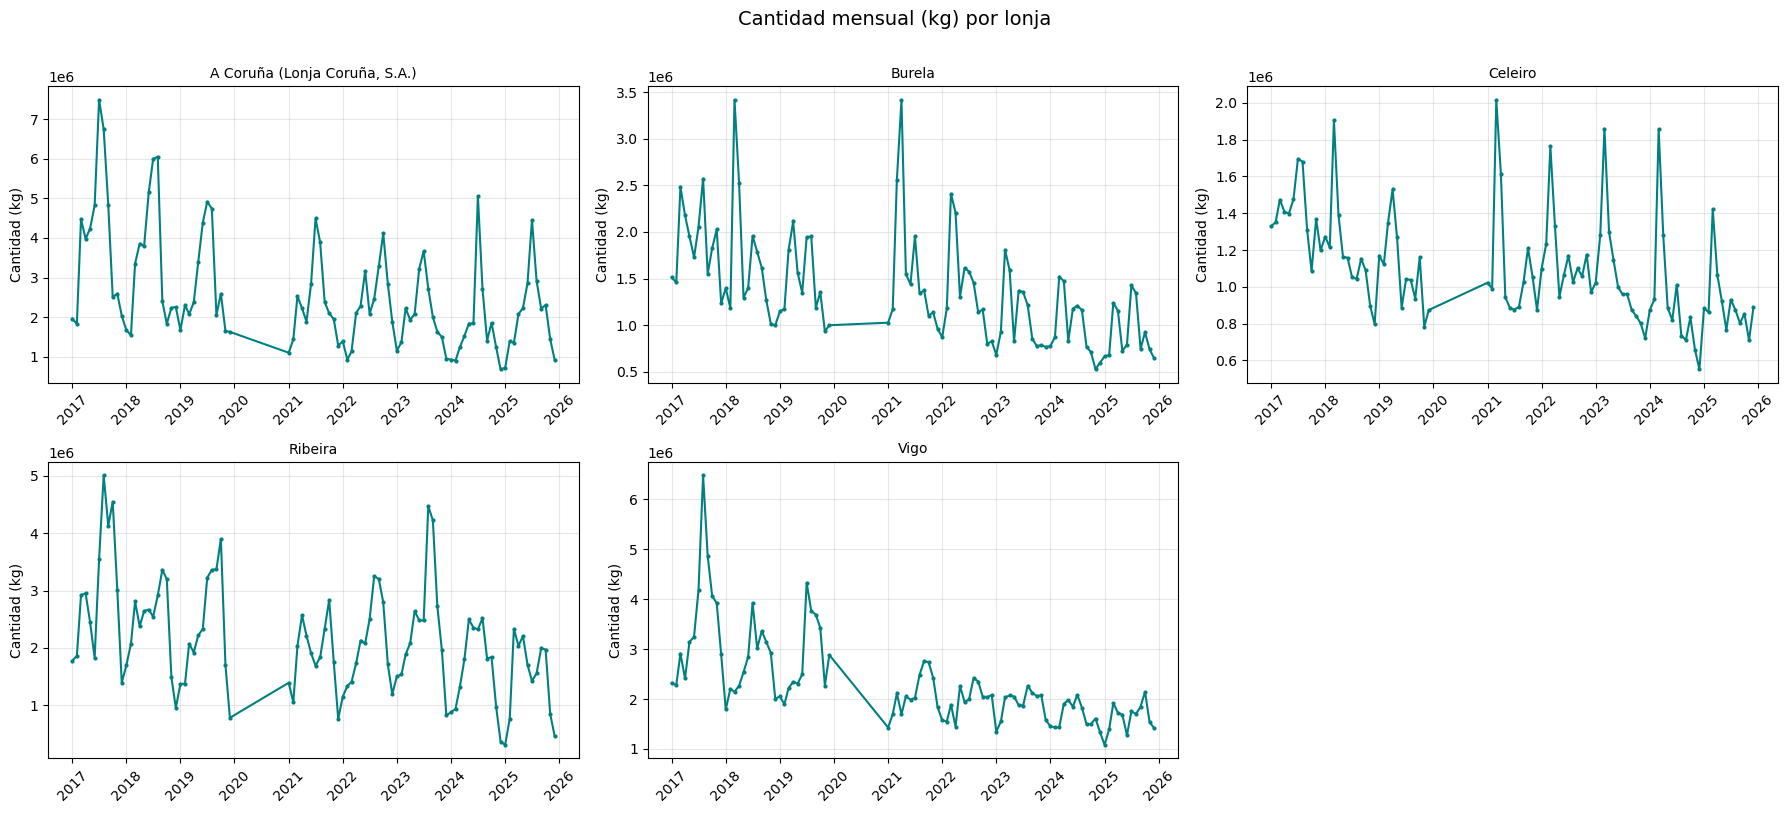

In [32]:
fig, axes = plt.subplots(
    nrows=(len(lonjas) + 2) // 3, ncols=3,
    figsize=(18, 4 * ((len(lonjas) + 2) // 3)),
    squeeze=False
)
for idx, lj in enumerate(lonjas):
    ax = axes[idx // 3][idx % 3]
    df_lj = df_pandas[df_pandas["lonxa"] == lj]
    ax.plot(df_lj["fecha"], df_lj["cantidad_total"], marker="o", markersize=2, color="teal")
    ax.set_title(lj, fontsize=10)
    ax.set_ylabel("Cantidad (kg)")
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

for idx in range(len(lonjas), axes.size):
    axes[idx // 3][idx % 3].set_visible(False)

plt.suptitle("Cantidad mensual (kg) por lonja", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Entrenamiento de un modelo XGBoost por lonja

Para cada lonja se sigue el mismo pipeline que en la versión agregada:
1. Crear features temporales: `lag_1`, `lag_12`, `media_3m`, `mes_sin`, `mes_cos`
2. Separar train (hasta dic-2023) / test (ene-2024+)
3. Entrenar XGBoost
4. Evaluar con RMSE, MAE, MAPE, R²

Las lonjas con menos de 24 meses de datos se omiten.

In [33]:
FEATURES = ["lag_1", "lag_12", "media_3m", "mes_sin", "mes_cos"]
TARGET = "cantidad_total"

resultados_pred = []
resultados_metricas = []

for lj in lonjas:
    print(f"\n{'='*60}")
    print(f"  LONJA: {lj}")
    print(f"{'='*60}")

    df_lj = df_pandas[df_pandas["lonxa"] == lj].copy().reset_index(drop=True)

    # Feature engineering
    df_lj["lag_1"]  = df_lj["cantidad_total"].shift(1)
    df_lj["lag_12"] = df_lj["cantidad_total"].shift(12)
    df_lj["media_3m"] = df_lj["cantidad_total"].rolling(window=3).mean()
    df_lj["mes_sin"] = np.sin(2 * np.pi * df_lj["mes"] / 12.0)
    df_lj["mes_cos"] = np.cos(2 * np.pi * df_lj["mes"] / 12.0)

    # Eliminar filas con NaN
    df_lj = df_lj.dropna().reset_index(drop=True)

    if len(df_lj) < 24:
        print(f"  OMITIDA: solo {len(df_lj)} meses (mínimo 24)")
        continue

    # Separación temporal train / test
    corte = df_lj["fecha"] < "2024-01-01"
    df_train = df_lj[corte].copy()
    df_test = df_lj[~corte].copy()

    if len(df_test) == 0:
        print(f"  OMITIDA: sin datos de test (todo anterior a 2024)")
        continue

    print(f"  Train: {len(df_train)} meses  |  Test: {len(df_test)} meses")

    X_train = df_train[FEATURES]
    y_train = df_train[TARGET]
    X_test = df_test[FEATURES]
    y_test = df_test[TARGET].values

    # Baseline: lag_12
    y_baseline = df_test["lag_12"].values

    rmse_bl = mean_squared_error(y_test, y_baseline) ** 0.5
    mae_bl = mean_absolute_error(y_test, y_baseline)
    mape_bl = mean_absolute_percentage_error(y_test, y_baseline)
    r2_bl = r2_score(y_test, y_baseline)

    # Entrenar XGBoost
    modelo_xgb = XGBRegressor(
        n_estimators=240,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.6,
        colsample_bytree=0.6,
        objective="reg:squarederror",
        random_state=42
    )
    modelo_xgb.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=0
    )

    # Predecir
    y_pred = modelo_xgb.predict(X_test)

    # Métricas
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mejora_mape = (1 - mape / mape_bl) * 100 if mape_bl > 0 else 0.0

    print(f"  XGBOOST:  RMSE={rmse:,.2f}  MAE={mae:,.2f}  MAPE={mape:.4f}  R²={r2:.4f}")
    print(f"  BASELINE: RMSE={rmse_bl:,.2f}  MAE={mae_bl:,.2f}  MAPE={mape_bl:.4f}  R²={r2_bl:.4f}")
    print(f"  Mejora MAPE: {mejora_mape:.1f}%")

    for i in range(len(df_test)):
        resultados_pred.append({
            "lonxa": lj,
            "fecha": df_test["fecha"].iloc[i],
            "cantidad_real": y_test[i],
            "cantidad_predicho": float(y_pred[i]),
            "error_absoluto": abs(y_test[i] - y_pred[i]),
            "error_pct": abs(y_test[i] - y_pred[i]) / y_test[i] * 100
        })

    resultados_metricas.append({
        "lonxa": lj,
        "rmse": float(rmse), "mae": float(mae),
        "mape": float(mape), "r2": float(r2),
        "baseline_rmse": float(rmse_bl), "baseline_mae": float(mae_bl),
        "baseline_mape": float(mape_bl), "baseline_r2": float(r2_bl),
        "mejora_mape_pct": float(mejora_mape)
    })

print(f"\n\nModelos entrenados: {len(resultados_metricas)} lonjas")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 42, Finished, Available, Finished, False)


  LONJA: A Coruña (Lonja Coruña, S.A.)
  Train: 60 meses  |  Test: 24 meses


  XGBOOST:  RMSE=613,431.74  MAE=320,090.87  MAPE=0.1737  R²=0.6688
  BASELINE: RMSE=611,450.42  MAE=487,607.59  MAPE=0.2830  R²=0.6710
  Mejora MAPE: 38.6%

  LONJA: Burela
  Train: 60 meses  |  Test: 24 meses


  XGBOOST:  RMSE=192,059.19  MAE=162,845.02  MAPE=0.1876  R²=0.5843
  BASELINE: RMSE=187,734.71  MAE=159,826.44  MAPE=0.1787  R²=0.6028
  Mejora MAPE: -5.0%

  LONJA: Celeiro
  Train: 60 meses  |  Test: 24 meses


  XGBOOST:  RMSE=162,548.48  MAE=151,358.40  MAPE=0.1788  R²=0.6242
  BASELINE: RMSE=179,701.01  MAE=136,180.83  MAPE=0.1563  R²=0.5407
  Mejora MAPE: -14.4%

  LONJA: Ribeira
  Train: 60 meses  |  Test: 24 meses


  XGBOOST:  RMSE=497,135.16  MAE=426,844.50  MAPE=0.4688  R²=0.4792
  BASELINE: RMSE=829,708.83  MAE=604,104.18  MAPE=0.4907  R²=-0.4507
  Mejora MAPE: 4.5%

  LONJA: Vigo
  Train: 60 meses  |  Test: 24 meses


  XGBOOST:  RMSE=278,809.47  MAE=224,018.81  MAPE=0.1528  R²=-0.1130
  BASELINE: RMSE=360,726.54  MAE=299,235.12  MAPE=0.1885  R²=-0.8631
  Mejora MAPE: 18.9%


Modelos entrenados: 5 lonjas


### Resumen de métricas por lonja

In [34]:
df_metricas = pd.DataFrame(resultados_metricas)
display(df_metricas.sort_values("mape"))

print(f"\nMAPE medio across lonjas: {df_metricas['mape'].mean():.4f}")
print(f"R² medio across lonjas:   {df_metricas['r2'].mean():.4f}")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 43, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, dd096e9f-2458-4349-b3fb-c8a2373e1b0f)


MAPE medio across lonjas: 0.2324
R² medio across lonjas:   0.4487


### Gráfico: valores reales vs predicciones por lonja

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 44, Finished, Available, Finished, False)

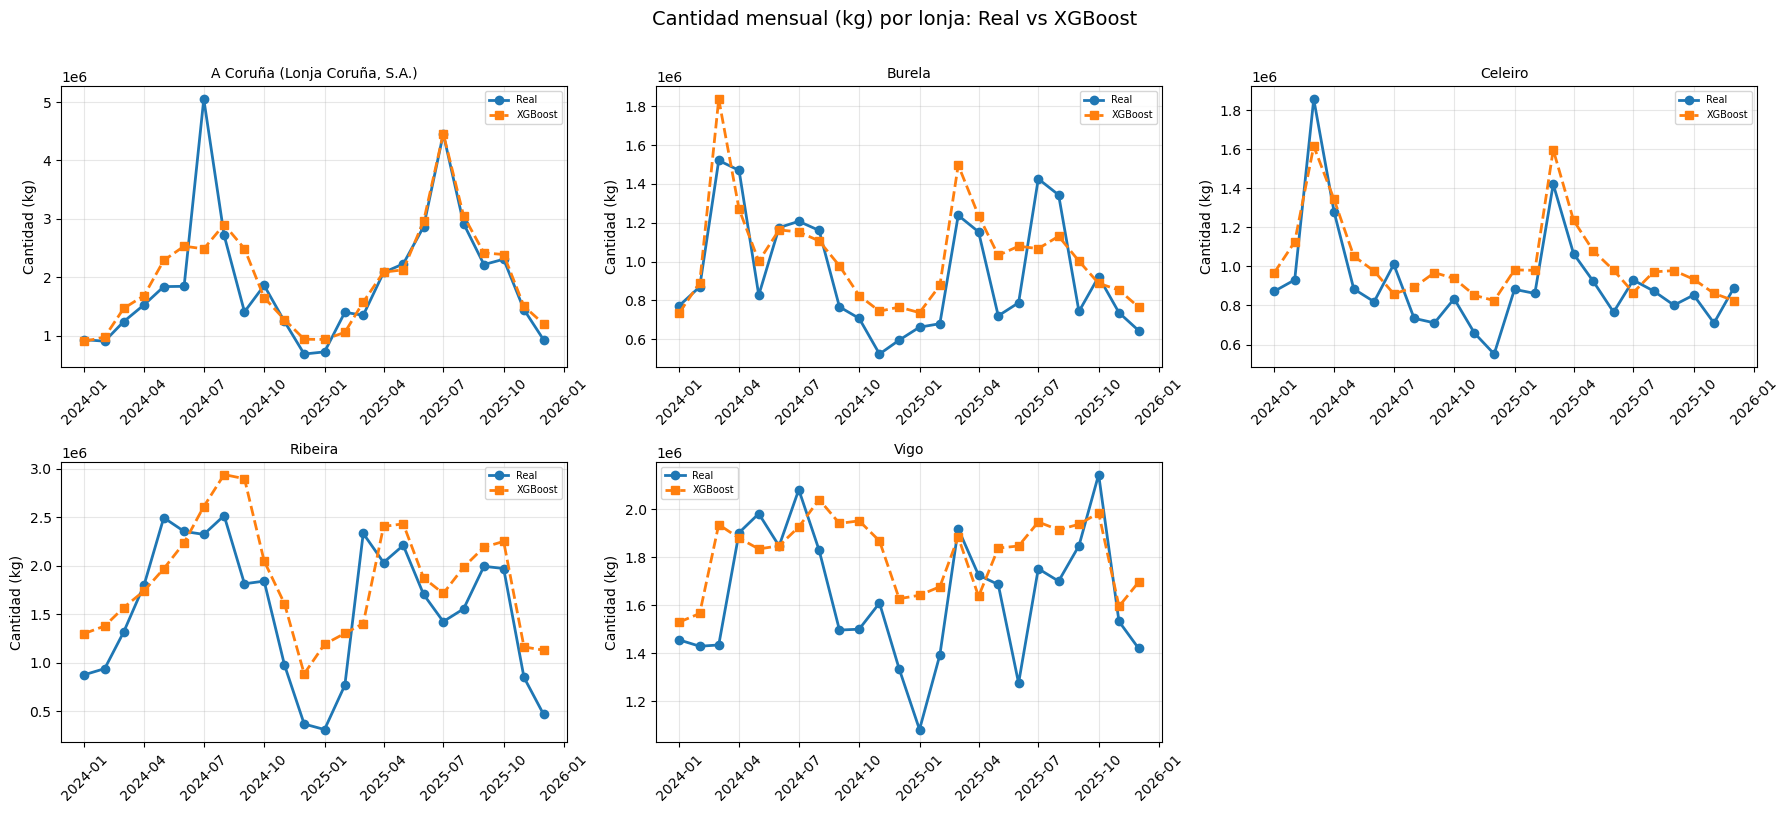

In [35]:
df_pred_all = pd.DataFrame(resultados_pred)
lonjas_pred = df_pred_all["lonxa"].unique()

fig, axes = plt.subplots(
    nrows=(len(lonjas_pred) + 2) // 3, ncols=3,
    figsize=(18, 4 * ((len(lonjas_pred) + 2) // 3)),
    squeeze=False
)
for idx, lj in enumerate(lonjas_pred):
    ax = axes[idx // 3][idx % 3]
    df_lj = df_pred_all[df_pred_all["lonxa"] == lj]
    ax.plot(df_lj["fecha"].values, df_lj["cantidad_real"].values,
            marker="o", label="Real", linewidth=2)
    ax.plot(df_lj["fecha"].values, df_lj["cantidad_predicho"].values,
            marker="s", label="XGBoost", linewidth=2, linestyle="--")
    ax.set_title(lj, fontsize=10)
    ax.set_ylabel("Cantidad (kg)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=45)

for idx in range(len(lonjas_pred), axes.size):
    axes[idx // 3][idx % 3].set_visible(False)

plt.suptitle("Cantidad mensual (kg) por lonja: Real vs XGBoost", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Registro en MLflow

In [36]:
mlflow.set_experiment("cantidad_mensual_por_lonxa")

with mlflow.start_run(run_name="xgboost_cantidad_por_lonxa"):

    mlflow.log_params({
        "modelo": "XGBoost_cantidad_por_lonxa",
        "target": "cantidad_total",
        "n_estimators": 240,
        "max_depth": 4,
        "learning_rate": 0.1,
        "subsample": 0.6,
        "colsample_bytree": 0.6,
        "features": str(FEATURES),
        "num_lonjas": len(resultados_metricas)
    })

    mlflow.log_metrics({
        "mape_medio": df_metricas["mape"].mean(),
        "r2_medio": df_metricas["r2"].mean(),
        "rmse_medio": df_metricas["rmse"].mean(),
        "mae_medio": df_metricas["mae"].mean(),
    })

    print("Métricas registradas en MLflow")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 45, Finished, Available, Finished, False)

Métricas registradas en MLflow


## Guardar predicciones en gold_predicciones_xgboost_cantidad_lonxa

In [37]:
df_pred_spark = spark.createDataFrame(df_pred_all)

df_pred_spark \
    .withColumn("modelo", lit("XGBoost_cantidad_por_lonxa")) \
    .withColumn("fecha_ejecucion", current_timestamp()) \
    .write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("gold_predicciones_xgboost_cantidad_lonxa")

print(f"Predicciones guardadas: {df_pred_spark.count()} filas")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 46, Finished, Available, Finished, False)

Predicciones guardadas: 120 filas


## Guardar métricas en gold_metricas_modelo

In [38]:
from datetime import datetime
from pyspark.sql.types import (
    StructType, StructField, StringType, DoubleType, TimestampType
)

schema = StructType([
    StructField("modelo", StringType()),
    StructField("lonxa", StringType()),
    StructField("rmse", DoubleType()),
    StructField("mae", DoubleType()),
    StructField("mape", DoubleType()),
    StructField("r2", DoubleType()),
    StructField("baseline_rmse", DoubleType()),
    StructField("baseline_mae", DoubleType()),
    StructField("baseline_mape", DoubleType()),
    StructField("baseline_r2", DoubleType()),
    StructField("mejora_mape_pct", DoubleType()),
    StructField("fecha_entrenamiento", TimestampType()),
    StructField("hiperparametros", StringType())
])

hiperparams = str({
    "n_estimators": 240,
    "max_depth": 4,
    "learning_rate": 0.1,
    "subsample": 0.6,
    "colsample_bytree": 0.6,
    "features": FEATURES
})

log_data = [
    (
        "XGBoost_cantidad_por_lonxa",
        row["lonxa"],
        row["rmse"], row["mae"], row["mape"], row["r2"],
        row["baseline_rmse"], row["baseline_mae"],
        row["baseline_mape"], row["baseline_r2"],
        row["mejora_mape_pct"],
        datetime.now(),
        hiperparams
    )
    for row in resultados_metricas
]

spark.createDataFrame(log_data, schema=schema) \
    .write \
    .format("delta") \
    .option("mergeSchema", "true") \
    .mode("append") \
    .saveAsTable("gold_metricas_modelo")

print("Métricas guardadas en gold_metricas_modelo")

StatementMeta(, 118d2509-d23e-4a46-82f2-9c72b8596e16, 47, Finished, Available, Finished, False)

Métricas guardadas en gold_metricas_modelo


In [56]:
from notebookutils import mssparkutils
mssparkutils.session.stop()